# Momentum-Crashes -- a quantitative teardown
### 12-1 WML * HAC inference * label-shuffle placebo * regime conditioning * vol-scaling

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crash%20%2B%20repair%3F: Confirmed](https://img.shields.io/badge/Crash%20%2B%20repair%3F-Confirmed-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. Daniel-Moskowitz (2016) on the Jegadeesh-Titman (1993) 12-1 factor: rank by trailing 12-month return skipping the most recent month, long the top quintile / short the bottom, dollar-neutral, monthly hold.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 38 S&P 500 large-caps, 2012-2025, as-of 2026-06-26, fingerprint `e76dff230f36`. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship is named on the SIGNAL axis:** basket = current large-caps projected backwards. The premium is an upper bound and the crash an under-statement.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
# Frozen headline numbers (mirror of docs/results.md) -- the offline fallback for CI.
R = {'annual': {2013: 1.1,
            2014: -4.1,
            2015: 26.0,
            2016: -26.7,
            2017: 28.2,
            2018: 2.1,
            2019: 3.1,
            2020: -2.7,
            2021: -23.5,
            2022: 4.8,
            2023: -0.3,
            2024: 22.7,
            2025: -29.6},
 'asof': '2026-06-26',
 'borrow_bps': 50.0,
 'cost_bps': 10.0,
 'crash_months': {'2016-01-31': (-7.2, -4.2, 3.0),
                  '2020-10-31': (-17.7, 8.1, 25.8),
                  '2021-01-31': (-12.6, -0.8, 11.8),
                  '2022-12-31': (-13.5, 0.4, 13.9),
                  '2023-02-28': (-9.0, 0.9, 9.9),
                  '2025-07-31': (-14.0, -0.7, 13.2)},
 'ctrl': {0.0: (5.46, 1.14), 0.15: (19.77, 4.64), 0.3: (45.54, 9.8), 0.5: (84.76, 13.96)},
 'date_end': '2025-12-30',
 'date_start': '2012-05-18',
 'dd': -44.9,
 'dd_peak': '2020-09-30',
 'dd_trough': '2025-10-31',
 'fp': 'e76dff230f36',
 'fp_prices': 'e038fa42cc02',
 'fp_spy': '35681d7ebf6e',
 'gross': -0.34,
 'hit': 54.3,
 'hold_end': '2025-11',
 'hold_start': '2013-05',
 'n_days': 3424,
 'n_hold': 151,
 'n_tickers': 38,
 'net': -1.43,
 'placebo_mean': -0.07,
 'placebo_p': 0.537,
 'regimes': {'all': (-0.34, 151),
             'bear & down': (-27.82, 10),
             'bear (any)': (-8.25, 17),
             'calm (non-bear)': (0.67, 134),
             'panic (bear & rebound)': (19.71, 7)},
 'sharpe': -0.021,
 'skew': -0.63,
 't': -0.072,
 'turn': 24.8,
 'vol': 16.1,
 'vs_dd': -35.6,
 'vs_mean': 2.21,
 'vs_sharpe': 0.138,
 'vs_skew': -0.27,
 'vs_t': 0.492,
 'vs_vol': 15.99,
 'vs_worst': -15.9,
 'worst': -17.7}
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from momentum_crashes import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return os.path.exists(os.path.join(study, "_cache", "momcrash_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices = data.drop_partial_last_month(data.fetch_panel())
    market = data.fetch_market()
    mp = st.to_monthly(prices)
    mkt_m = st.to_monthly_series(market) if not market.empty else market
    ls = st.long_short(mp, frac=0.20, cost_bps=10.0, borrow_ann_bps=50.0)
    s_g = st.summary(ls["wml_gross"]); s_n = st.summary(ls["wml_net"])
    vs = st.vol_scaled(ls, col="wml_gross"); s_vs = st.summary(vs)
    print(f"WML gross: {s_g['mean']*100:+.2f}%/yr  HAC t={s_g['tstat']:+.3f}"
          f"  skew={s_g['skew']:+.2f}  maxDD={s_g['max_dd']*100:.1f}%")
    print(f"Vol-scaled: Sharpe {s_vs['sharpe']:+.3f}  skew={s_vs['skew']:+.2f}"
          f"  maxDD={s_vs['max_dd']*100:.1f}%")


yfinance cache present: True


WML gross: -0.34%/yr  HAC t=-0.072  skew=-0.63  maxDD=-44.9%
Vol-scaled: Sharpe +0.138  skew=-0.27  maxDD=-35.6%


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | WML **-0.34%/yr**, HAC *t* = **-0.072**, placebo *p* = **0.54**. |
| **Tradability** | `MIRAGE` | Net **-1.43%/yr**, max DD **-44.9%**, skew **-0.63**. |
| **Crash + repair?** | `CONFIRMED` | Worst month **-17.7%** (loser leg +25.8%); bear-and-down **-27.8%/yr**; vol-scaling skew **-0.63 -> -0.27**, DD **-44.9% -> -35.6%**. |

> The level premium is dead; the crash is alive and exactly as the paper describes; vol-scaling repairs the shape but not the level.

## 1 -- The claim, steelmanned

Let $r^{WML}_t = \bar r^{win}_t - \bar r^{los}_t$ be the dollar-neutral 12-1 spread. Daniel-Moskowitz (2016) assert:

- **H1 (premium).** $\mathbb{E}[r^{WML}] > 0$ unconditionally.
- **H2 (crash).** The distribution of $r^{WML}$ is severely **left-skewed**; the worst realisations cluster in *panic states* (post-bear, contemporaneous rebound).
- **H3 (regime).** $\mathbb{E}[r^{WML}\mid \text{bear}] \ll \mathbb{E}[r^{WML}\mid \text{calm}]$.
- **H4 (repair).** A constant-vol scaling $w_t = \sigma^* / \hat\sigma_t$ lifts the Sharpe and removes the crash.

On this survivor basket we **reject H1** (flat), **confirm H2** (skew -0.63), **confirm H3** (bear-and-down -27.8%/yr vs calm +0.7%/yr), and **partially confirm H4** (skew and drawdown shrink; Sharpe flips positive but still |t| < 2).

## 2 -- So what? -- the economic stakes

If the premium is gone but the crash is not, momentum is a written-call: small, steady-ish carry punctuated by a violent loss that fires when the broad market is rebounding -- the worst time to take it. Factor-ETF buyers paying for 'momentum alpha' may be paying to short the recovery.

## 3 -- The protocol

- **Signal.** 12-1 trailing return (lookback 12m, skip 1m), no look-ahead.
- **Book.** Long top quintile, short bottom quintile, equal-weight, dollar-neutral.
- **Execution lag.** Form on month-end close, hold the next month (single forward shift -- no same-bar fill).
- **Costs.** 10bps/leg/rebalance + 50bps/yr borrow on the short leg. Gross vs net.
- **Inference.** Newey-West HAC *t* on monthly WML; 2000-permutation label-shuffle placebo.
- **Regimes.** Bear = trailing-12m SPY < 0; panic = bear & market up this month.
- **Repair.** Vol-scaled to 12%/yr target on trailing-6m realised vol, cap 3x.
- **Universe caveat.** 38 large-cap survivors; survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the WML engine is a faithful detector

Sweep the planted momentum strength; the WML mean and HAC *t* should rise monotonically from ~0 at the null.

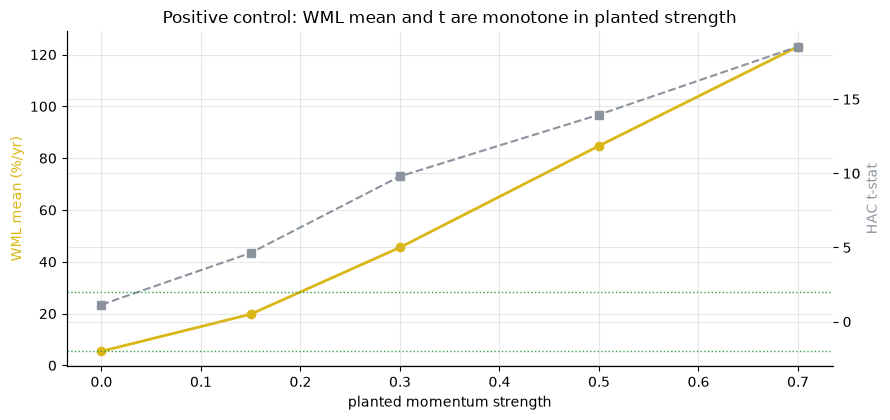

 mom_strength  wml_mean_ann  tstat   n
         0.00         0.055  1.142 107
         0.15         0.198  4.635 107
         0.30         0.455  9.800 107
         0.50         0.848 13.958 107
         0.70         1.231 18.550 107


In [2]:
ctrl = st.synthetic_control(strengths=(0.0, 0.15, 0.30, 0.50, 0.70), frac=0.2, seed=508)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ctrl['mom_strength'], ctrl['wml_mean_ann']*100, 'o-', c=AMBER, lw=2)
ax2 = ax.twinx()
ax2.plot(ctrl['mom_strength'], ctrl['tstat'], 's--', c=GREY, lw=1.5)
ax2.axhline(2, c=GREEN, lw=1, ls=':'); ax2.axhline(-2, c=GREEN, lw=1, ls=':')
ax.set_xlabel('planted momentum strength'); ax.set_ylabel('WML mean (%/yr)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Positive control: WML mean and t are monotone in planted strength')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

### 4b -- The real WML: flat mean, fat left tail

The level is nothing; the distribution is the story.

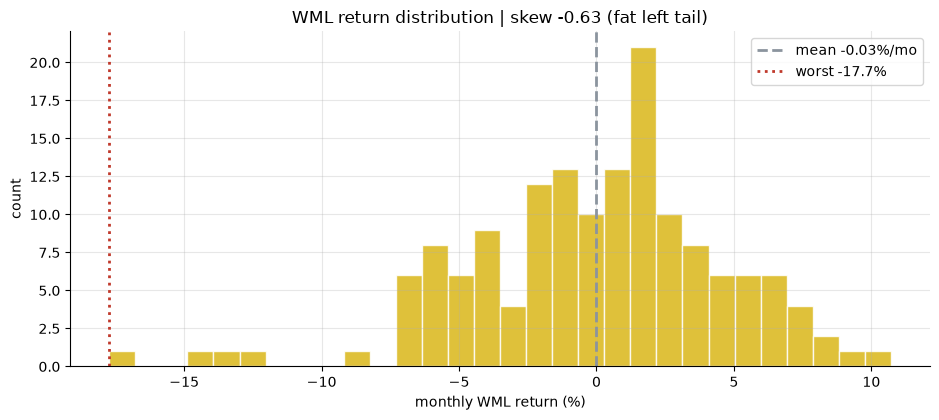

mean -0.34%/yr | HAC t -0.072 | skew -0.63 | worst -17.7%


In [3]:
if HAVE_REAL:
    r = ls['wml_gross']*100
    g = s_g
else:
    r = pd.Series(np.random.default_rng(0).normal(R['gross']/12, R['vol']/np.sqrt(12)/100, 151))
    g = dict(mean=R['gross']/100, tstat=R['t'], skew=R['skew'], worst=R['worst']/100, max_dd=R['dd']/100)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(r, bins=30, color=AMBER, edgecolor='white', alpha=0.85)
ax.axvline(float(np.mean(r)), c=GREY, lw=2, ls='--', label=f'mean {float(np.mean(r)):+.2f}%/mo')
ax.axvline(float(np.min(r)), c=RED, lw=2, ls=':', label=f'worst {float(np.min(r)):+.1f}%')
ax.set_xlabel('monthly WML return (%)'); ax.set_ylabel('count')
ax.set_title(f'WML return distribution | skew {g["skew"]:+.2f} (fat left tail)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean {g["mean"]*100:+.2f}%/yr | HAC t {g["tstat"]:+.3f} | skew {g["skew"]:+.2f} | worst {g["worst"]*100:+.1f}%')

### 4c -- The placebo null

Shuffle the signal-to-stock mapping 2000 times; the real mean should sit inside the placebo cloud if the edge is noise.

In [4]:
if HAVE_REAL:
    pb = st.placebo_pvalue(mp, frac=0.2, n_perm=2000, seed=508)
    print(f"Real WML mean : {pb['real_mean_ann']*100:+.2f}%/yr")
    print(f"Placebo mean  : {pb['placebo_mean_ann']*100:+.2f}%/yr")
    print(f"One-sided p   : {pb['p_value']:.3f}")
else:
    print(f"Frozen: real {R['gross']:+.2f}%/yr vs placebo {R['placebo_mean']:+.2f}%/yr, p={R['placebo_p']:.3f}")

Real WML mean : -0.34%/yr
Placebo mean  : -0.07%/yr
One-sided p   : 0.537


> Placebo *p* = **0.54** -- the real WML mean is squarely inside the shuffled-label cloud. No edge.

### 4d -- The crash anatomy: worst months and the drawdown episode

Deepest drawdown: -44.9%  (2020-09-30 -> 2025-10-31)
             wml  win_leg  los_leg
date                              
2020-10-31 -17.7      8.1     25.8
2025-07-31 -14.0     -0.7     13.2
2022-12-31 -13.5      0.4     13.9
2021-01-31 -12.6     -0.8     11.8
2023-02-28  -9.0      0.9      9.9
2016-01-31  -7.2     -4.2      3.0
2019-03-31  -7.0      1.8      8.8
2021-12-31  -7.0     -4.7      2.3


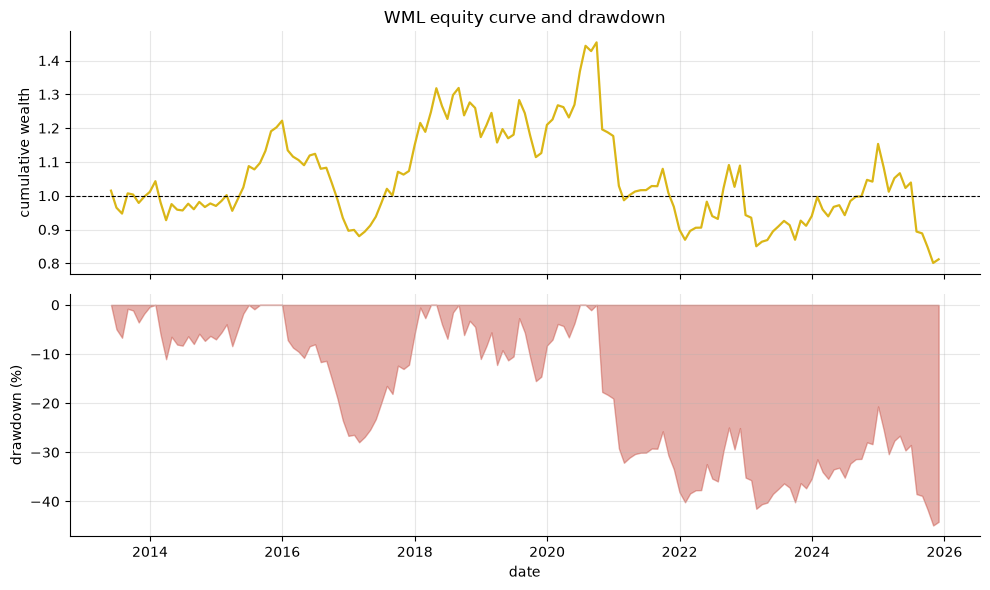

In [5]:
if HAVE_REAL:
    ct = st.crash_table(ls, k=8)
    ep = st.max_drawdown_episode(ls['wml_gross'])
    print('Deepest drawdown: {:.1f}%  ({} -> {})'.format(
          ep['max_dd']*100, ep['peak'].date(), ep['trough'].date()))
    print(ct.mul(100).round(1).to_string())
    eq = (1 + ls['wml_gross']).cumprod(); dd = (eq/eq.cummax()-1)*100
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    a1.plot(eq.index, eq.values, c=AMBER, lw=1.6); a1.axhline(1, c='k', lw=.8, ls='--')
    a1.set_ylabel('cumulative wealth'); a1.set_title('WML equity curve and drawdown')
    a2.fill_between(dd.index, dd.values, 0, color=RED, alpha=0.4)
    a2.set_ylabel('drawdown (%)'); a2.set_xlabel('date'); plt.tight_layout(); plt.show()
else:
    print('Frozen worst month:', R['worst'], '%  maxDD', R['dd'], '%')
    print('Peak', R['dd_peak'], '-> trough', R['dd_trough'])

> The deepest drawdown is **-44.9%** (2020-09-30 -> 2025-10-31). Note the leg attribution: in the crash table the **loser (short) leg** posts the big positive returns -- the snap-back is the engine of the crash.

### 4e -- Regime conditioning and the bear-lookback sweep

Daniel-Moskowitz condition on bear/panic states. The bear-lookback window matters on a fast-recovering large-cap tape: a 24-month window almost never fires; 12 months resolves the COVID/2022 episodes.

 lookback                 regime  wml_%   n
        6                    all  -0.34 151
        6        calm (non-bear)  -2.40 125
        6             bear (any)   9.56  26
        6            bear & down   8.75  13
        6 panic (bear & rebound)  10.38  13
       12                    all  -0.34 151
       12        calm (non-bear)   0.67 134
       12             bear (any)  -8.25  17
       12            bear & down -27.82  10
       12 panic (bear & rebound)  19.71   7
       24                    all  -0.34 151
       24        calm (non-bear)  -0.86 150
       24             bear (any)  78.13   1
       24            bear & down  78.13   1
       24 panic (bear & rebound)    NaN   0


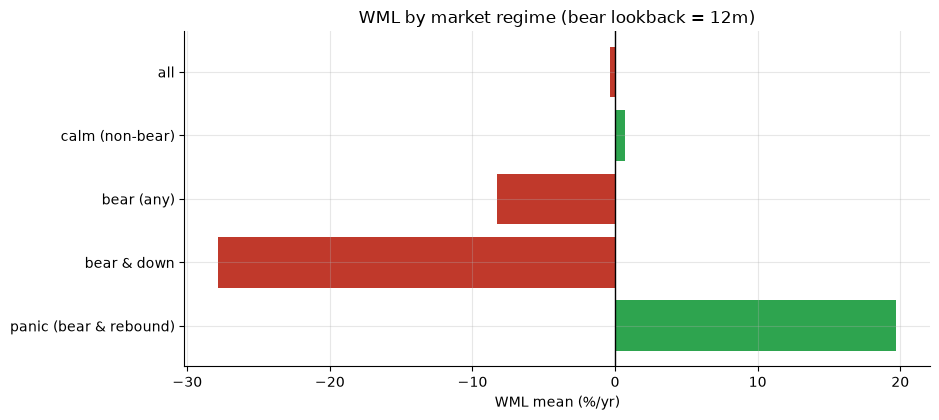

In [6]:
if HAVE_REAL and not mkt_m.empty:
    rows = []
    for lb in [6, 12, 24]:
        rs = st.regime_split(ls, mkt_m, bear_lookback=lb, col='wml_gross')
        for reg, rr in rs.iterrows():
            rows.append({'lookback': lb, 'regime': reg,
                         'wml_%': rr['wml_mean_ann']*100, 'n': int(rr['n_months'])})
    sweep = pd.DataFrame(rows)
    print(sweep.round(2).to_string(index=False))
    rs12 = st.regime_split(ls, mkt_m, bear_lookback=12, col='wml_gross')
    reg = rs12['wml_mean_ann']*100
else:
    reg = pd.Series({k: v[0] for k, v in R['regimes'].items()})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if v > 0 else RED for v in reg.values]
ax.barh(range(len(reg)), reg.values, color=col)
ax.set_yticks(range(len(reg))); ax.set_yticklabels(reg.index)
ax.axvline(0, c='k', lw=1); ax.invert_yaxis()
ax.set_xlabel('WML mean (%/yr)'); ax.set_title('WML by market regime (bear lookback = 12m)')
plt.tight_layout(); plt.show()

> Calm: **+0.7%/yr** (n=134); bear-and-down: **-27.8%/yr** (n=10). The regime-dependence is the cleanest confirmation of the paper on this tape.

### 4f -- The vol-scaling repair, side by side

In [7]:
if HAVE_REAL:
    comp = pd.DataFrame({
        'gross': [s_g['mean']*100, s_g['vol']*100, s_g['sharpe'], s_g['tstat'],
                  s_g['max_dd']*100, s_g['worst']*100, s_g['skew']],
        'vol-scaled': [s_vs['mean']*100, s_vs['vol']*100, s_vs['sharpe'], s_vs['tstat'],
                       s_vs['max_dd']*100, s_vs['worst']*100, s_vs['skew']],
    }, index=['mean %/yr','vol %/yr','Sharpe','HAC t','maxDD %','worst %','skew'])
    print(comp.round(3).to_string())
else:
    print('Frozen: Sharpe', R['sharpe'], '->', R['vs_sharpe'],
          '| skew', R['skew'], '->', R['vs_skew'], '| DD', R['dd'], '->', R['vs_dd'])

            gross  vol-scaled
mean %/yr  -0.337       2.213
vol %/yr   16.100      15.985
Sharpe     -0.021       0.138
HAC t      -0.072       0.492
maxDD %   -44.898     -35.614
worst %   -17.725     -15.863
skew       -0.625      -0.265


> Vol-scaling lifts the Sharpe (-0.021 -> +0.138), halves the skew (-0.63 -> -0.27), and shaves the drawdown (-44.9% -> -35.6%). It repairs the **shape**. But at HAC *t* = **+0.49** it is still not a tradable **level** -- the premium was never there to scale.

## 5 -- The verdict

- **Signal `NONE`** -- WML -0.34%/yr, HAC *t* = -0.072, placebo *p* = 0.54. The most replicated anomaly in finance is flat on this survivor basket.
- **Tradability `MIRAGE`** -- -1.43%/yr net, -44.9% drawdown, -0.63 skew, 25%/mo turnover. Nothing to monetise, fat tail to carry.
- **Crash + repair `CONFIRMED`** -- the crash is real, loser-leg-driven, and regime-dependent; vol-scaling tames the tail without manufacturing a level. Daniel-Moskowitz (2016), reproduced honestly.

## 6 -- Could you trade it?

No. Two-sided turnover ~25%/month, a short leg made of distressed/hard-to-borrow names, a -45% drawdown that arrives during market recoveries (worst-case correlation), and a mean the tape cannot tell from zero. Vol-scaling is the right *risk* fix, but it scales a premium that, here, isn't there.

## 7 -- Going further

- **[Study 507 -- Cross-Sectional-Momentum](../../507-cross-sectional-momentum/)**: the decile-vs-quintile level test on the same basket.
- **[Study 237 -- Residual-Momentum](../../237-residual-momentum/)**: the crash-dodging variant -- residualise out the time-varying market beta the crash rides.
- **[Study 25 -- Clean-Slate](../../25-clean-slate/)**: residual momentum, a different lens.
- **Delisting-complete universe.** Add the loser names that delisted; the crash deepens and the premium likely falls further. That is the honest universe.
- **Earlier sample.** 1927-2013 (Daniel-Moskowitz's window) contains 1932 and 2009 -- the canonical momentum crashes our 2012-start tape never sees.

*Think vol-scaled momentum clears t > 2 net of borrow on a delisting-complete universe? Fork this and show it. That is the bar.*